In [6]:
import pandas as pd

# 1. Load all datasets using clean relative paths
customers_df = pd.read_csv("data/customers.csv")
orders_df = pd.read_csv("data/orders.csv")
tickets_df = pd.read_csv("data/support_tickets.csv")
web_df = pd.read_csv("data/web_events_snapshot.csv")
labels_df = pd.read_csv("data/churn_labels.csv")
intervention_df = pd.read_csv("data/intervention_history.csv")
rfm_df = pd.read_csv("data/rfm_modeling_snapshot.csv")

# 2. Store them in a dictionary for easy looping
datasets = {
    "Customers": customers_df, 
    "Orders": orders_df, 
    "Support Tickets": tickets_df,
    "Web Events": web_df, 
    "Churn Labels": labels_df, 
    "Interventions": intervention_df, 
    "RFM Snapshot": rfm_df
}

# 3. Print the shapes to verify successful loading
print("--- Dataset Shapes ---")
for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

--- Dataset Shapes ---
Customers: 2400 rows, 9 columns
Orders: 10009 rows, 10 columns
Support Tickets: 1921 rows, 8 columns
Web Events: 2400 rows, 10 columns
Churn Labels: 2400 rows, 4 columns
Interventions: 2400 rows, 5 columns
RFM Snapshot: 2400 rows, 29 columns


In [7]:
print("================ DATA QUALITY AUDIT ================\n")

# 1. MISSING VALUES SWEEP
print("--- 1. Missing Values ---")
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing_cols = missing[missing > 0]
    if not missing_cols.empty:
        print(f"{name}:")
        for col, count in missing_cols.items():
            print(f"  - {col}: {count} missing ({(count/len(df))*100:.1f}%)")
print("\n")

# 2. DUPLICATES SWEEP
print("--- 2. Full Row Duplicates ---")
for name, df in datasets.items():
    dupes = df.duplicated().sum()
    if dupes > 0:
        print(f"{name}: {dupes} duplicate rows")
print("Orders with '_DUP' in ID:", orders_df['order_id'].str.endswith('_DUP', na=False).sum())
print("\n")

# 3. JOIN INTEGRITY (ORPHAN CHECK)
print("--- 3. Join Integrity ---")
valid_customers = set(customers_df['customer_id'])
orphan_orders = orders_df[~orders_df['customer_id'].isin(valid_customers)]
orphan_tickets = tickets_df[~tickets_df['customer_id'].isin(valid_customers)]
print(f"Orders from unknown customers: {len(orphan_orders)}")
print(f"Tickets from unknown customers: {len(orphan_tickets)}")
print("\n")

# 4. LOGICAL TRAPS & LEAKAGE
print("--- 4. Logical Traps & Outliers ---")
# Leakage Check
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
snapshot_date = pd.to_datetime('2025-09-30')
leaked_orders = orders_df[orders_df['order_date'] > snapshot_date]
print(f"Leaked Post-Snapshot Orders: {len(leaked_orders)}")

# Outlier Check
max_order = orders_df['gross_amount'].max()
print(f"Maximum Order Value: ₹{max_order} (Avg is ~₹744)")

# Negative Value Check
negative_tickets = tickets_df[tickets_df['resolution_hours'] < 0]
print(f"Tickets with negative resolution hours: {len(negative_tickets)}")

invalid_sentiment = tickets_df[(tickets_df['sentiment_score'] < -1.0) | (tickets_df['sentiment_score'] > 1.0)]
print(f"Tickets with invalid sentiment scores: {len(invalid_sentiment)}")

================ DATA QUALITY AUDIT ================

--- 1. Missing Values ---
Customers:
  - loyalty_tier: 1386 missing (57.8%)
  - skin_type: 401 missing (16.7%)
Orders:
  - rating: 80 missing (0.8%)
RFM Snapshot:
  - loyalty_tier: 1386 missing (57.8%)


--- 2. Full Row Duplicates ---
Orders with '_DUP' in ID: 12


--- 3. Join Integrity ---
Orders from unknown customers: 0
Tickets from unknown customers: 0


--- 4. Logical Traps & Outliers ---
Leaked Post-Snapshot Orders: 1872
Maximum Order Value: ₹24789.38 (Avg is ~₹744)
Tickets with negative resolution hours: 0
Tickets with invalid sentiment scores: 0


/var/folders/bc/vbq9jny179nbt12vstt7gtwh0000gn/T/ipykernel_28566/25416.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=eda_df, x='churn_next_60d', palette='Set2')


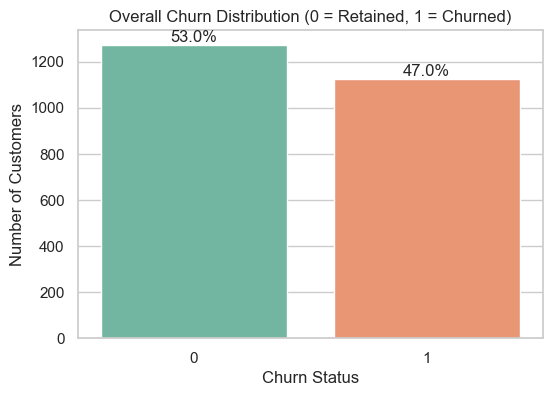

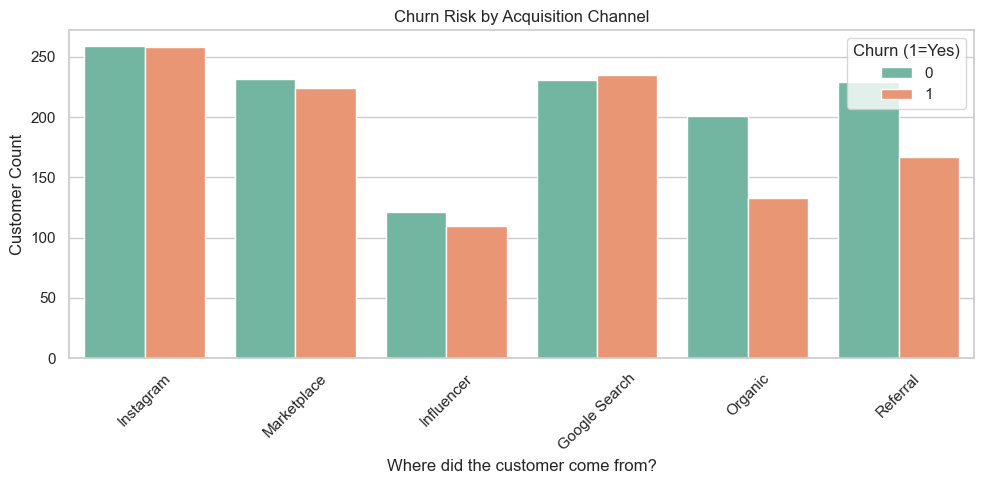

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for our charts
sns.set_theme(style="whitegrid")

# 1. HARD CLEANING: Remove the leakage and duplicates!
orders_clean = orders_df[~orders_df['order_id'].str.endswith('_DUP', na=False)]
orders_clean = orders_clean[orders_clean['order_date'] <= '2025-09-30']

# 2. LIGHT CLEANING FOR CHARTS: Fill missing categorical values
customers_df['loyalty_tier'] = customers_df['loyalty_tier'].fillna('Not Enrolled')

# 3. Build the Master EDA Dataframe
# Join Customers with their Churn Labels so we know who left
eda_df = pd.merge(customers_df, labels_df[['customer_id', 'churn_next_60d']], on='customer_id', how='left')

# 4. Chart 1: The Baseline Churn Rate
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=eda_df, x='churn_next_60d', palette='Set2')
plt.title("Overall Churn Distribution (0 = Retained, 1 = Churned)")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
# Add percentages on top of bars
total = len(eda_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
# Save the chart BEFORE showing it!
plt.savefig("outputs/chart1_overall_churn.png", bbox_inches='tight')
plt.show()


# 5. Chart 2: Churn by Acquisition Channel
plt.figure(figsize=(10, 5))
sns.countplot(data=eda_df, x='acquisition_channel', hue='churn_next_60d', palette='Set2')
plt.title("Churn Risk by Acquisition Channel")
plt.xlabel("Where did the customer come from?")
plt.ylabel("Customer Count")
plt.xticks(rotation=45)
plt.legend(title='Churn (1=Yes)')
plt.tight_layout()
# Save the chart BEFORE showing it!
plt.savefig("outputs/chart2_churn_by_channel.png", bbox_inches='tight')
plt.show()

/var/folders/bc/vbq9jny179nbt12vstt7gtwh0000gn/T/ipykernel_28566/58455229.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_master, x='churn_next_60d', y='ticket_count_90d', palette='Set2')


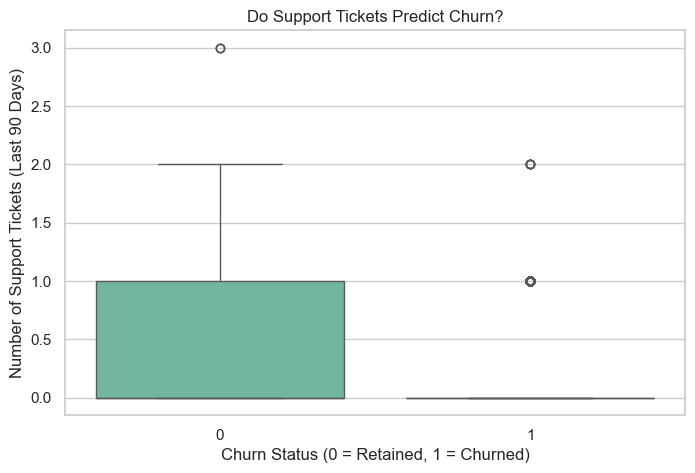

/var/folders/bc/vbq9jny179nbt12vstt7gtwh0000gn/T/ipykernel_28566/58455229.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_master, x='churn_next_60d', y='last_visit_days_ago', palette='Set2')


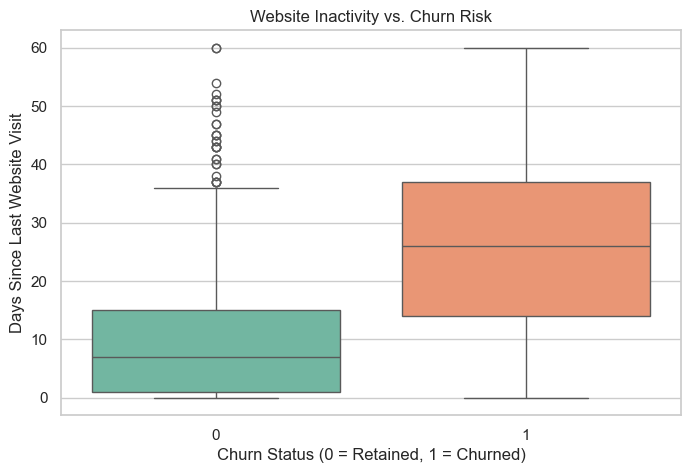

/var/folders/bc/vbq9jny179nbt12vstt7gtwh0000gn/T/ipykernel_28566/58455229.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_master, x='churn_next_60d', y='avg_discount_pct_180d', palette='Set2')


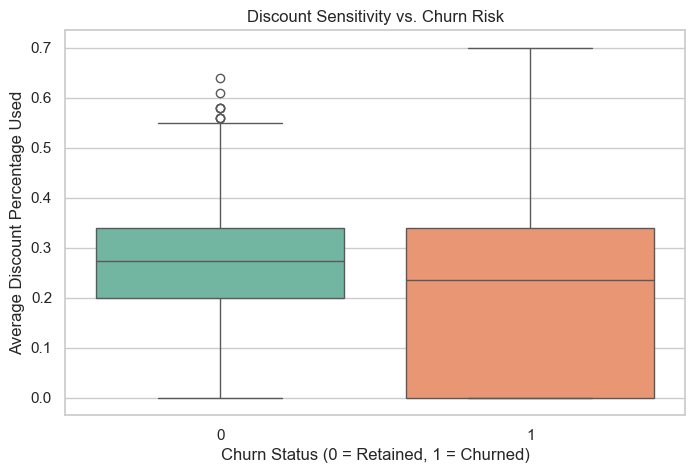

In [9]:
# 1. Merge in the safe, pre-calculated snapshot data
eda_master = pd.merge(eda_df, rfm_df[['customer_id', 'ticket_count_90d', 'last_visit_days_ago', 'avg_discount_pct_180d']], on='customer_id', how='left')

# 2. Chart 3: Support Tickets vs. Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=eda_master, x='churn_next_60d', y='ticket_count_90d', palette='Set2')
plt.title("Do Support Tickets Predict Churn?")
plt.xlabel("Churn Status (0 = Retained, 1 = Churned)")
plt.ylabel("Number of Support Tickets (Last 90 Days)")
# Save the chart BEFORE showing it!
plt.savefig("outputs/chart3_support_tickets_vs_churn.png", bbox_inches='tight')
plt.show()

# 3. Chart 4: Web Activity vs. Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=eda_master, x='churn_next_60d', y='last_visit_days_ago', palette='Set2')
plt.title("Website Inactivity vs. Churn Risk")
plt.xlabel("Churn Status (0 = Retained, 1 = Churned)")
plt.ylabel("Days Since Last Website Visit")
# Save the chart BEFORE showing it!
plt.savefig("outputs/chart4_web_activity_vs_churn.png", bbox_inches='tight')
plt.show()

# 4. Chart 5: Discount Usage vs. Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=eda_master, x='churn_next_60d', y='avg_discount_pct_180d', palette='Set2')
plt.title("Discount Sensitivity vs. Churn Risk")
plt.xlabel("Churn Status (0 = Retained, 1 = Churned)")
plt.ylabel("Average Discount Percentage Used")
# Save the chart BEFORE showing it!
plt.savefig("outputs/chart5_discount_usage_vs_churn.png", bbox_inches='tight')
plt.show()

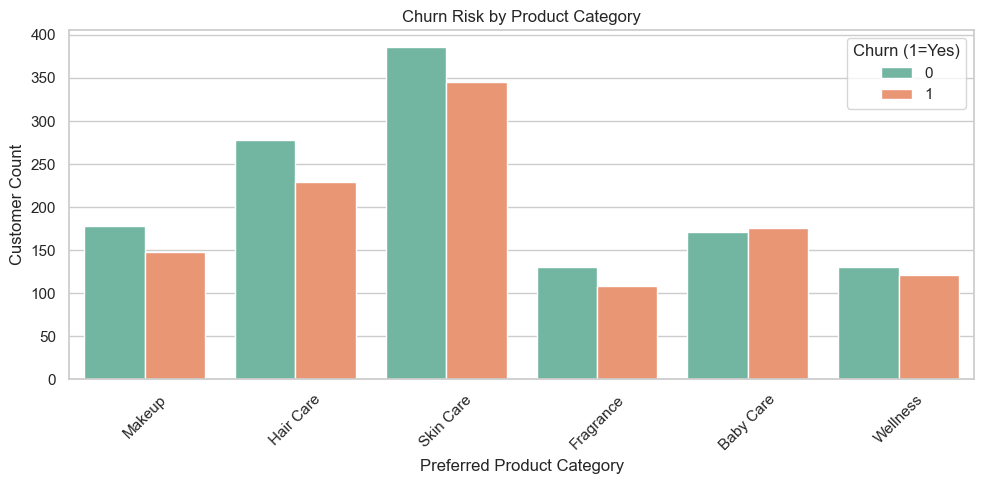

In [10]:
# Chart 6: Churn by Preferred Category
plt.figure(figsize=(10, 5))
sns.countplot(data=eda_master, x='preferred_category', hue='churn_next_60d', palette='Set2')
plt.title("Churn Risk by Product Category")
plt.xlabel("Preferred Product Category")
plt.ylabel("Customer Count")
plt.xticks(rotation=45)
plt.legend(title='Churn (1=Yes)')
plt.tight_layout()
# Save the chart BEFORE showing it!
plt.savefig("outputs/chart6_churn_by_category.png", bbox_inches='tight')
plt.show()